# Proyecto #2: Clases y Objetos

### Integrantes: Sebastián Calvo Solano, Isaac Rodríguez Zuñiga

### Colegio Universitario de Cartago

### Programación 2




In [ ]:
import sys
from pathlib import Path

import pandas as pd

raiz_proyecto = Path(Path.cwd()).parent
sys.path.append(str(raiz_proyecto / "src"))


In [10]:
from src.ingesta.CargadorDatos import CargadorDatos
from src.gestor.GestorPartidos import GestorPartidos
from eda.EDA import ProcesadorEDA as EDA

cargador = CargadorDatos(
    url_source="https://raw.githubusercontent.com/martj42/international_results/master/results.csv",
    raw_path="../data/raw",
    processed_path="../data/processed"
)
df_raw = cargador.ejecutar()
gestor = GestorPartidos(df_raw)
df = EDA(gestor)


INFO:src.ingesta.CargadorDatos:Descargando CSV desde https://raw.githubusercontent.com/martj42/international_results/master/results.csv
INFO:src.ingesta.CargadorDatos:Descarga completa, dimension de: 49509 filas y 9 columnas
INFO:src.ingesta.CargadorDatos:Filtro aplicado para 'FIFA World Cup': 1068 filas
INFO:src.ingesta.CargadorDatos:Guardado raw en: ..\data\raw\raw_results.csv
INFO:src.ingesta.CargadorDatos:Guardado processed en: ..\data\raw\partidos-mundial.csv


## EDA

El Análisis Exploratorio de Datos es una técnica que permite observar los datos de manera superficial para encontrar patrones y/o tendencias.

A continuación veremos algunos datos que nos mostró el EDA realizado.

#### Llamado de Clases y Librerías

In [11]:
# Llamado de librerías
import sys
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt

raiz_proyecto = Path(Path.cwd()).parent
sys.path.append(str(raiz_proyecto / "src"))

from eda.EDA import ProcesadorEDA as EDA
from ingesta.CargadorDatos import CargadorDatos


Ahora se procede con la creación de la clase

In [12]:
# Definición de la clase
class ProcesadorEDA:
    def __init__(self, gestor: GestorPartidos):
        self._gestor = gestor
        self._df = gestor.df
        self._filas = self._df.shape[0]
        self._columnas = self._df.shape[1]

    @property
    def df(self) -> pd.DataFrame:
        return self._df.copy()

    @property
    def columnas(self) -> int:
        return self._columnas

    @property
    def filas(self) -> int:
        return self._filas

En este caso solo utilizamos un guión bajo "_" debido a que son atributos internos.

## Creación de Atributos

Una vez el objeto está creado ahora procedemos a darle atributos a este.

#### Visualización de Primeros Datos

In [13]:
    # Vista de primeros 15 elementos
    def primerosDatos(self):
        pd.set_option('display.max_rows', self._columnas)
        return print(self._df.head(n = 15))

    # Vista de últimos 15 elementos
    def ultimososDatos(self):
        pd.set_option('display.max_rows', self._columnas)
        return print(self._df.tail(n = 15))


In [15]:
df.primerosDatos()


           date  home_team      away_team  home_score  away_score  \
1490 1930-07-13    Belgium  United States         0.0         3.0   
1491 1930-07-13     France         Mexico         4.0         1.0   
1492 1930-07-14     Brazil     Yugoslavia         1.0         2.0   
1493 1930-07-14       Peru        Romania         1.0         3.0   
1494 1930-07-15  Argentina         France         1.0         0.0   
...         ...        ...            ...         ...         ...   
1501 1930-07-19      Chile         France         1.0         0.0   
1502 1930-07-20    Belgium       Paraguay         0.0         1.0   
1503 1930-07-20    Bolivia         Brazil         0.0         4.0   
1504 1930-07-21    Uruguay        Romania         4.0         0.0   
1505 1930-07-22  Argentina          Chile         3.0         1.0   

          tournament        city  country  neutral  \
1490  FIFA World Cup  Montevideo  Uruguay     True   
1491  FIFA World Cup  Montevideo  Uruguay     True   
1492  FIF

In [16]:
df.ultimososDatos()

            date      home_team    away_team  home_score  away_score  \
49494 2026-07-04       Paraguay       France         0.0         1.0   
49495 2026-07-05         Brazil       Norway         1.0         2.0   
49496 2026-07-05         Mexico      England         2.0         3.0   
49497 2026-07-06       Portugal        Spain         0.0         1.0   
49498 2026-07-06  United States      Belgium         1.0         4.0   
...          ...            ...          ...         ...         ...   
49504 2026-07-11      Argentina  Switzerland         3.0         1.0   
49505 2026-07-14         France        Spain         NaN         NaN   
49506 2026-07-15        England    Argentina         NaN         NaN   
49507 2026-07-18            NaN          NaN         NaN         NaN   
49508 2026-07-19            NaN          NaN         NaN         NaN   

           tournament             city        country  neutral  \
49494  FIFA World Cup     Philadelphia  United States     True   
494

Cargamos los primeros y últimos 15 datos para verificar que todo se encuentre de manera correcta, esto nos permite ver información como que el primer mundial se jugó en 1930 o que la sede fue Uruguay.

#### Matriz de Correlación

In [18]:
    # Matriz de Correlación
    def correlacion(self):
        filtro_numerico = self._df.select_dtypes(['number']) # Se filtran solo los datos numéricos
        m_correlacion = filtro_numerico.corr()
        print("Matriz de Correlacion")
        return m_correlacion

In [19]:
df.correlacion()

Matriz de Correlacion


,home_score,away_score
home_score,1.000000,-0.060505
away_score,-0.060505,1.000000


Observamos que la correlación es casi nula "-0.06", esto se debe a que si un equipo mete goles no afecta nada en el gol rival.

#### Descripción General

In [20]:
    # Descripción
    def descripcion(self):
        descripcion = self._df.describe()
        return descripcion

In [21]:
df.descripcion()

,date,home_score,away_score
count,1068,1064.000000,1064.000000
mean,1993-04-26 21:18:12.134831,1.583647,1.247180
min,1930-07-13 00:00:00,0.000000,0.000000
25%,1974-07-03 00:00:00,0.750000,0.000000
50%,1998-06-16 12:00:00,1.000000,1.000000
75%,2014-06-21 06:00:00,2.000000,2.000000
max,2026-07-19 00:00:00,10.000000,8.000000
std,NaN,1.493969,1.285271


Gracias al atributo descripción podemos observar información sobre los datos que se almacenan en las columnas, en este caso vemos tres columnas en específico:
- date
- home_score
- away_score

Observamos que en ambas estadísticas de gol poseen una media de 1, el 75% de los datos están entre el 0 y el 2 y el máximo en "home_score" es de 10 y "away_score" es de 8

#### Boxplot

In [23]:
    # Revisión de outliers en goles de local y visita
    def outliers(self):
        goles_local = self._df['home_score'].dropna()
        goles_visita = self._df['away_score'].dropna()
        # Al final se ingresa el dropna para evitar errores

        fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
        ax.boxplot([goles_local, goles_visita], showfliers=True)
        ax.set_xticklabels(['Goles Local', 'Goles Visita'])
        # Creamos el lienzo del gráfico y le pasamos los datos a utilizar

        ax.set_title('Distribución y Comparativa de Goles en los Mundiales', fontsize=13, fontweight='bold', pad=15)
        ax.set_ylabel('Cantidad de Goles por Partido', fontsize=11)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Esto quita la línea de arriba y de la derecha del lienzo, lo cual evita que parezca una caja

        return plt.show()

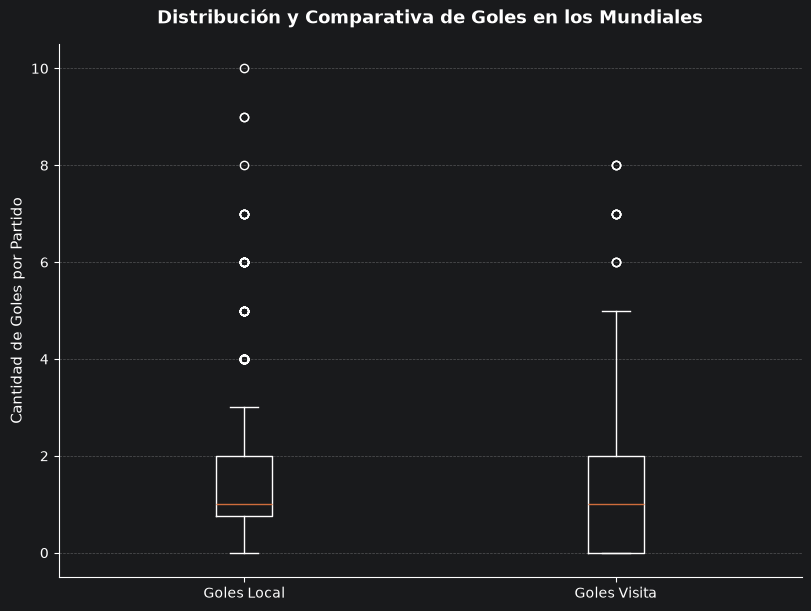

In [24]:
df.outliers()

Por medio de estos gráficos de cajas (boxplot) podemos observar de manera visual lo que veíamos en la descripción.

Observamos como al menos en gol visita la mayoría de datos están entre 0 y 2 goles anotados en cambio en gol local están entre el 1 y 2, además, vemos que los outliers aparecen mas rápido con goles anotados, a diferencia de gol visita que hasta 6 goles anotados es que empiezan a aparecer los outliers.

#### Goles Marcados

In [26]:
    # Países con mas goles marcados
    def goles_favor(self):
        goles_local = self._df.groupby('home_team')['home_score'].sum()
        goles_visita = self._df.groupby('away_team')['away_score'].sum()
        # Los paréntesis cuadrados "[]" permiten acceder a los valores de las columnas, estos son los que se suman

        goles_totales = goles_local.add(goles_visita, fill_value=0)
        goles_totales = goles_totales.astype(int).sort_values(ascending=False)
        # Se suman los goles y se transforman en enteros para mejor legibilidad

        resultados = goles_totales.reset_index(name='Goles Anotados')
        resultados.columns = ['Selección', 'Goles Anotados']
        # Se reinician los índices para agregar nuevos y se sustituye "index" por "Selección"

        return resultados


In [27]:
df.goles_favor()

,Selección,Goles Anotados
0,Brazil,247
1,Germany,243
2,Argentina,169
3,France,152
4,Italy,128
...,...,...
81,El Salvador,1
82,Israel,1
83,China,0
84,Indonesia,0


Vemos que Alemania y Brasil son los dos países que mas goles han anotado y tienen mayor diferencia con respecto a los demás lugares del top ambos con mas de 240 goles y el tercer lugar es Argentina con 169, siendo esta una diferencia de mas de 70 goles.

#### Goles Recibidos

In [28]:
    # Equipos con mas goles recibidos
    def goles_contra(self):
        recibidos_visita = self._df.groupby('away_team')['home_score'].sum()
        recibidos_local = self._df.groupby('home_team')['away_score'].sum()
        # Se comparan los goles con los equipos en este caso los contrarios (gol visita al equipo local y viceversa)

        goles_totales = recibidos_local.add(recibidos_visita, fill_value=0)
        goles_totales = goles_totales.sort_values(ascending=False)
        goles_totales = goles_totales.astype(int).sort_values(ascending=False)
        # Se suman los goles y se transforman en enteros para mejor legibilidad

        resultados = goles_totales.reset_index(name='Goles Recibidos')
        resultados.columns = ['Selección', 'Goles Recibidos']
        # Se reinician los índices para agregar nuevos y se sustituye "index" por "Selección"

        return resultados

In [29]:
df.goles_contra()

,Selección,Goles Recibidos
0,Germany,135
1,Brazil,112
2,Argentina,107
3,Mexico,104
4,France,87
...,...,...
81,Cape Verde,5
82,Iceland,5
83,Trinidad and Tobago,4
84,Israel,3


Observamos como es el mismo top 3 solamente que las distancias entre estas son mas cercanas, Alemania en esta ocación es la que está primera y se suma México dentro del top 5, esto nos dice que son selecciones que poseen muchas participaciones en los mundiales.

#### Diferencia de Goles

In [35]:
    def diferencia_goles(self):
        goles_favor = self.goles_favor()
        goles_contra = self.goles_contra()
        # Llama la función anteriormente creadas y los guarda en una variable

        goles_favor = pd.DataFrame(goles_favor).sort_values(by='Selección', ascending=False)
        goles_contra = pd.DataFrame(goles_contra).sort_values(by='Selección', ascending=False)
        # Se agregan ambas tablas y se ordenan por orden alfabético

        tabla_goles = pd.merge(goles_favor, goles_contra, on='Selección', how='outer')
        tabla_goles = tabla_goles.fillna(0)
        tabla_goles['Diferencia Goles'] = tabla_goles['Goles Anotados'] - tabla_goles['Goles Recibidos']
        # Se realiza la resto entre ambas tablas de goles para obtener la diferencia de gol

        columnas_num = ['Goles Anotados', 'Goles Recibidos', 'Diferencia Goles']
        tabla_goles[columnas_num] = tabla_goles[columnas_num].astype(int)
        tabla_goles = tabla_goles.sort_values(by='Diferencia Goles', ascending=False)
        # Las columnas se cambian a numéricas para mejor legibilidad

        return tabla_goles

In [36]:
df.diferencia_goles()

,Selección,Goles Anotados,Goles Recibidos,Diferencia Goles
8,Brazil,247,112,135
30,Germany,243,135,108
28,France,152,87,65
2,Argentina,169,107,62
41,Italy,128,77,51
...,...,...,...,...
10,Cameroon,22,47,-25
9,Bulgaria,22,53,-31
47,Mexico,72,104,-32
64,Saudi Arabia,15,49,-34


Brasil obtiene el primer puesto con el doble de puntos que el tercer puesto que es Francia, Alemania es segundo con un diferencia no tan marcada, esta tabla es importante ya que no refleja que tan buenas son las selecciones tanto defendiendo como atacando y que tanto estas avanzan en este torneo.

#### Victorias

In [37]:
    # Equipos con mas victorias
    def victorias(self):
        df_gana_local = self._df[self._df['home_score'] > self._df['away_score']]
        # El ".size()" cuenta cuántas victorias obtuvo cada equipo
        victorias_local = df_gana_local.groupby('home_team').size()
        df_gana_visita = self._df[self._df['away_score'] > self._df['home_score']]
        # Compara los goles de visita y local y si son diferentes los guarda en una variable

        victorias_visita = df_gana_visita.groupby('away_team').size()
        victorias_totales = victorias_local.add(victorias_visita, fill_value=0)
        victorias_totales = victorias_totales.astype(int).sort_values(ascending=False)
        # Se convierten en enteros ya que ".add" los convierte en flotantes (float)
        # Se suman las victorias locales y visitantes y se transforman en enteros ya que no requieren decimales

        resultados = pd.DataFrame(victorias_totales, columns= ["Cantidad de Victorias"])
        resultados = victorias_totales.reset_index(name='Cantidad de Victorias')
        resultados.columns = ['Selección', 'Cantidad de Victorias']

        return resultados


In [38]:
df.victorias()

,Selección,Cantidad de Victorias
0,Brazil,79
1,Germany,70
2,Argentina,53
3,Italy,45
4,France,45
...,...,...
60,Czech Republic,1
61,North Korea,1
62,Slovenia,1
63,Slovakia,1


Este gráfico nos muestra algo muy importante ya que entre mas victorias posee un equipo refleja no solo su participación sino que además muestra el desempeño que han tenido en este torneo, una selección con muchas victorias como Brasil o Alemania refleja que es una selección que no solo participa mucho sino que suele quedar entre las primeras posiciones.

#### Derrotas

In [39]:
    # Equipos con mas victorias
    def victorias(self):
        df_gana_local = self._df[self._df['home_score'] > self._df['away_score']]
        # El ".size()" cuenta cuántas victorias obtuvo cada equipo
        victorias_local = df_gana_local.groupby('home_team').size()
        df_gana_visita = self._df[self._df['away_score'] > self._df['home_score']]
        # Compara los goles de visita y local y si son diferentes los guarda en una variable

        victorias_visita = df_gana_visita.groupby('away_team').size()
        victorias_totales = victorias_local.add(victorias_visita, fill_value=0)
        victorias_totales = victorias_totales.astype(int).sort_values(ascending=False)
        # Se convierten en enteros ya que ".add" los convierte en flotantes (float)
        # Se suman las victorias locales y visitantes y se transforman en enteros ya que no requieren decimales

        resultados = pd.DataFrame(victorias_totales, columns= ["Cantidad de Victorias"])
        resultados = victorias_totales.reset_index(name='Cantidad de Victorias')
        resultados.columns = ['Selección', 'Cantidad de Victorias']

        return resultados


    # Equipos con mas derrotas
    def derrotas(self):
        df_derrota_local = self._df[self._df['home_score'] < self._df['away_score']]
        derrotas_local = df_derrota_local.groupby('home_team').size()
        df_derrota_visita = self._df[self._df['away_score'] < self._df['home_score']]
        # Compara los goles de visita y local y si son diferentes los guarda en una variable

        derrotas_visita = df_derrota_visita.groupby('away_team').size()
        derrotas_totales = derrotas_local.add(derrotas_visita, fill_value=0)
        derrotas_totales = derrotas_totales.astype(int).sort_values(ascending=False)
        # Se suman las derrotas locales y visitantes y se transforman en enteros ya que no requieren decimales

        resultados = pd.DataFrame(derrotas_totales, columns=["Cantidad de Derrotas"])
        resultados = derrotas_totales.reset_index(name='Cantidad de Derrotas')
        resultados.columns = ['Selección', 'Cantidad de Derrotas']

        return resultados


In [40]:
df.derrotas()

,Selección,Cantidad de Derrotas
0,Mexico,29
1,Argentina,24
2,Germany,24
3,South Korea,23
4,United States,22
...,...,...
81,Angola,1
82,Cuba,1
83,Cape Verde,1
84,Israel,1


Este apartado es importante porque también nos dice la constancia de estos equipos en cuantos a participaciones en el torneo y que tanto llegan a avanzar, observamos que México lidera el primer puesto, hecho que hace sentido con su aparición en los equipos que mas goles han encajado.

#### Empates

In [41]:
    # Equipos con mas empates
    def empates(self):
        df_empate_local = self._df[self._df['home_score'] == self._df['away_score']]
        empates_local = df_empate_local.groupby('home_team').size()
        df_empate_visita = self._df[self._df['away_score'] == self._df['home_score']]
        # Compara los goles de visita y local y si son iguales los guarda en una variable

        empates_visita = df_empate_visita.groupby('away_team').size()
        empates_totales = empates_local.add(empates_visita, fill_value=0)
        empates_totales = empates_totales.astype(int).sort_values(ascending=False)
        # Se suman los empates locales y visitantes y se transforman en enteros ya que no requieren decimales

        resultados = pd.DataFrame(empates_totales, columns=["Cantidad de Empates"])
        resultados = empates_totales.reset_index(name='Cantidad de Empates')
        resultados.columns = ['Selección', 'Cantidad de Empates']
        # Se resetean los índices y se agrega junto a la selección correspondiente

        return resultados

In [42]:
df.empates()

,Selección,Cantidad de Empates
0,England,23
1,Germany,22
2,Italy,21
3,Brazil,20
4,Spain,18
...,...,...
70,Slovenia,1
71,Slovakia,1
72,Ukraine,1
73,Trinidad and Tobago,1


Observamos que el empate es el resultado menos frecuente en un partido, motivo por el cual vemos que no hay mucha distancia entre puesto y puesto.

#### Mundiales con mas Goles

In [43]:
    # Mundial con mas goles
    def mas_gol_mundial(self):
        sede = self._df.copy()
        sede['Año'] = sede['date'].dt.year
        # "lambda" realiza la función de devolver los años con mas de una sede en un mismo lugar
        sede['Sede'] = sede.groupby('Año')['country'].transform(lambda x: ' / '.join(sorted(x.unique())))
        # Esto permite evitar usar una función aparte, ya que "lambda" funciona como un operario temporal

        goles_totales = sede.groupby(['Sede', 'Año'])[['home_score', 'away_score']].sum()
        goles_totales['Goles Anotados'] = goles_totales['home_score'] + goles_totales['away_score']
        goles_ordenados = goles_totales['Goles Anotados'].astype(int).sort_values(ascending=False)
        # Se suman los goles de los equipos locales y visitantes y se agrupan a los mundiales correspondientes

        resultados = goles_ordenados.reset_index(name='Goles Anotados')
        resultados.columns = ['Sede(s)', 'Año', 'Goles Anotados']
        # Se resetean los índices y se agrega el nuevo "Goles Anotados" junto a la sede y al año

        return resultados.head(n = 11)

In [44]:
df.mas_gol_mundial()

,Sede(s),Año,Goles Anotados
0,Canada / Mexico / United States,2026,292
1,Qatar,2022,172
2,Brazil,2014,171
3,France,1998,171
4,Russia,2018,169
...,...,...,...
6,Germany,2006,147
7,Spain,1982,146
8,South Africa,2010,145
9,United States,1994,141


Esto nos da los mundiales con mayor cantidad de goles en la historia, observamos una apabuyante diferencia entre el primer puesto con el resto de la tabla ya que son mas de 120 goles de diferencia, además, observamos que la mayoría de mundiales en el top son de este siglo, lo cual refleja como el deporte ha evolucionado a lo largo de la historia.

#### Mundial con menos Goles

In [45]:
    # Mundial con menos goles
    def menos_gol_mundial(self):
        sede = self._df.copy()
        sede['Año'] = sede['date'].dt.year
        sede['Sede'] = sede.groupby('Año')['country'].transform(lambda x: ' / '.join(sorted(x.unique())))
        # Se filtra la sede y en caso de ser varias se pone como una misma gracias a "lambda"

        goles_totales = sede.groupby(['Sede', 'Año'])[['home_score', 'away_score']].sum()
        goles_totales['Goles Anotados'] = goles_totales['home_score'] + goles_totales['away_score']
        goles_ordenados = goles_totales['Goles Anotados'].astype(int).sort_values(ascending=True)
        # Se suman los goles de los equipos locales y visitantes y se agrupan a los mundiales correspondientes

        resultados = goles_ordenados.reset_index(name='Goles Anotados')
        resultados.columns = ['Sede(s)', 'Año', 'Goles Anotados']
        # Se resetean los índices y se agrega el nuevo "Goles Anotados" junto a la sede y al año

        return resultados.head(n = 11)

In [46]:
df.menos_gol_mundial()

,Sede(s),Año,Goles Anotados
0,Italy,1934,70
1,Uruguay,1930,70
2,France,1938,84
3,Brazil,1950,88
4,England,1966,89
...,...,...,...
6,Mexico,1970,95
7,Germany,1974,97
8,Argentina,1978,102
9,Italy,1990,115


Se nos muestra como justamente los mundiales con menos goles eran los primeros, esto nos da un reflejo tanto del deporte como del torneo en sí, ya que este ha sufrido cambios que han reflejado la evolución y aumento de dicha cantidad.

#### Cantidad de Veces que un País fue Sede

In [47]:
    # País que mas veces a sido sede, año en que fue y equipo campeón
    def veces_sede(self):
        sede = self._df.copy()
        sede['Año'] = sede['date'].dt.year
        indices_finales = sede.groupby('Año')['date'].idxmax()

        # Se filtra el dataset para buscar el último partido disputado (razón por la que se excluye 2026)
        finales = sede.loc[indices_finales].copy()
        finales = finales[finales['Año'] != 2026]

        # Función para obtener el campeón según los goles del último partido, gracias a finales
        def obtener_campeon(fila):
            if fila['home_score'] > fila['away_score']:
                return fila['home_team']
            else:
                return fila['away_team']

        finales['Campeón'] = finales.apply(obtener_campeon, axis=1)
        diccionario_campeones = finales.set_index('Año')['Campeón'].to_dict()
        sedes_unicas = sede[['Año', 'country']].drop_duplicates()

        # El campeón es agregado al año correspondiente
        sedes_unicas['Campeón'] = sedes_unicas['Año'].map(diccionario_campeones)

        # 2026 se deja nulo y se cambia por "Por Definir" para evitar conflictos de inserción con ".join"
        sedes_unicas['Campeón'] = sedes_unicas['Campeón'].fillna('Por Definir')

        # Se agrupan los datos que se van a mostrar
        resultados = sedes_unicas.groupby('country').agg(
            Veces_Sede=('Año', 'count'),
            # Si no dice "Por Definir" este agregua al campeón, así evitamos un campeón en 2026
            Campeones_Sede=('Campeón', lambda x: ', '.join([c for c in x.unique() if c != 'Por Definir'])),
            # Se transforma en str para que no de error
            Anho_Sede=('Año', lambda x: ', '.join(sorted(x.unique().astype(str))))
        ).reset_index()

        # Se cambia el orden de las tablas para mayor legibilidad
        resultados.columns = ['País Sede', 'Veces Sede', 'Campeón(es) Coronado(s)', 'Año(s)']
        resultados = resultados.sort_values(by='Veces Sede', ascending=False)

        return resultados

In [48]:
df.veces_sede()

,País Sede,Veces Sede,Campeón(es) Coronado(s),Año(s)
9,Mexico,3,"Brazil, Argentina","1970, 1986, 2026"
6,Germany,2,"Germany, France","1974, 2006"
1,Brazil,2,"Uruguay, Germany","1950, 2014"
17,United States,2,Italy,"1994, 2026"
5,France,2,"Brazil, France","1938, 1998"
...,...,...,...,...
12,South Africa,1,Spain,2010
14,Spain,1,Italy,1982
15,Sweden,1,Brazil,1958
16,Switzerland,1,Germany,1954


En este gráfico además de observar la cantidad de veces que un país fue sede y el año en el que fue, también se nos muestra cuales países han salido campeonas en dicha edición.

#### Desempeño Histórico

In [49]:
    def ranking_mundial(self):
        diferencia_goles = self.diferencia_goles()
        victorias = self.victorias()
        derrotas = self.derrotas()
        empates = self.empates()
        # Llaman las funciones necesarias para trabajar

        ranking = pd.merge(victorias, empates, on='Selección', how='outer') \
                     .merge(derrotas, on='Selección', how='outer') \
                     .merge(diferencia_goles, on='Selección', how='outer')

        ranking = ranking.fillna(0)
        ranking['Puntos'] = (ranking['Cantidad de Victorias'] * 3) + (ranking['Cantidad de Empates'] * 1)
        enteros = ['Cantidad de Victorias', 'Cantidad de Derrotas', 'Cantidad de Empates',
                   'Goles Anotados', 'Goles Recibidos', 'Diferencia Goles', 'Puntos']
        ranking[enteros] = ranking[enteros].astype(int)
        ranking = ranking.sort_values(by='Puntos', ascending=False)
        ranking = ranking.reset_index(drop=True)

        return ranking

In [50]:
df.ranking_mundial()

,Selección,Cantidad de Victorias,Cantidad de Empates,Cantidad de Derrotas,Goles Anotados,Goles Recibidos,Diferencia Goles,Puntos
0,Brazil,79,20,20,247,112,135,257
1,Germany,70,22,24,243,135,108,232
2,Argentina,53,17,24,169,107,62,176
3,Italy,45,21,17,128,77,51,156
4,France,45,14,20,152,87,65,149
...,...,...,...,...,...,...,...,...
81,Indonesia,0,0,1,0,6,-6,0
82,Panama,0,0,6,2,15,-13,0
83,Togo,0,0,3,1,6,-5,0
84,United Arab Emirates,0,0,3,2,11,-9,0


Por último obtenemos un ranking de desempeño de las selecciones a lo largo de la historia en los mundiales, se escogió el sistema actual de puntos para crear la lista, es decir:
- Victoria: 3 puntos
- Empate: 1 punto
- Derrota: 0 puntos

De esta manera se puede hacer de una manera clara cuales han sido históricamente las mejores selecciones en mundiales desde que su creación en 1930.